In [1]:
import xgboost as xgb
from xgboost import XGBRegressor, DMatrix, train as xgb_train
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Concatenate, Embedding, Flatten
from tensorflow.keras.optimizers import Adam, SGD, RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
from tensorflow.keras.regularizers import l1, l2
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler, OneHotEncoder, PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString
import folium
from scipy import stats, optimize
from folium.plugins import Draw
from IPython.display import display, HTML, IFrame
import ast
import joblib
import joblib
from joblib import Parallel, delayed
from tqdm import tqdm
import time
import warnings
import logging

In [2]:
# Suppress specific warnings from XGBoost
warnings.filterwarnings(action='ignore', category=UserWarning, message='.*deprecated.*')
warnings.filterwarnings(action='ignore', category=UserWarning, message='.*not used.*')
warnings.filterwarnings(action='ignore', category=UserWarning, message='.*No visible GPU is found.*')


In [3]:
display(HTML("""
<style>
.jp-OutputArea-output {
    overflow-y: auto;
}
</style>
"""))


In [4]:
# Load the dataset
file_path = r'C:\Users\Prakhar.Sarkar\OneDrive - SRP Management Services\Documents\_For_Prakhar\Sample data from Vesna vLandedWells.xlsx'  
df = pd.read_excel(file_path)

In [5]:
# Read the first Excel sheet (cumulative data)
file_path = r'C:\Users\Prakhar.Sarkar\OneDrive - SRP Management Services\Documents\_For_Prakhar\Cumulative Prod for sample data.xlsx'
cumulative_df = pd.read_excel(file_path)

In [6]:
df = pd.merge(df, cumulative_df, on='UWI10', how='left')

In [7]:
# Identify rows in df that do not have a match in cumulative_df
no_match_df = df[df['Cumulative oil mbo'].isnull() & 
                        df['Cumulative gas mmcf'].isnull() & 
                        df['Cumulative water mbbl'].isnull()]
# Print the UWI10 values that did not have a match
if no_match_df.empty:
    print("All UWI10 values in the detailed well data have corresponding matches in the cumulative data.")
else:
    print("UWI10 values in the detailed well data that did not have a corresponding match in the cumulative data:")
    print(no_match_df['UWI10'].tolist())

    # Print the rows with no matching cumulative data
    print("\nRows with no matching cumulative data:")
    print(no_match_df)

UWI10 values in the detailed well data that did not have a corresponding match in the cumulative data:
[4231739846, 4231745088, 4231742586, 4231743077, 4231742706, 4231742957, 4231744274, 4231741133, 4231744299, 4231741625, 4231742348, 4231743929, 4231741974, 4222738740, 4231743680, 4231743123, 4231740964, 4231744025, 4231742393, 4231743949, 4231742628, 4231741518, 4231740773, 4231744700, 4231744406, 4231741742, 4231739610, 4231744242, 4231739461, 4231744280, 4231739891, 4231740757, 4222741501, 4231740770, 4231742769, 4231743757, 4231741072, 4231743858, 4231740168, 4231742731, 4231739863, 4231743107, 4231742998, 4231743100, 4231741508, 4231743917, 4231740738, 4231744053, 4222740293, 4231742382, 4231741245, 4231741599]

Rows with no matching cumulative data:
         UWI10             UWI                             WellName  \
0   4231739846  42317398460000                   SALE RANCH 20E #5H   
1   4231745088  42317450880000       AMOCO-BLANCHE 2-28 UNIT 1 #115   
2   4231742586  423

In [8]:
def robust_parse(x):
    if pd.isna(x):
        return [None] * 7  # Handle NaNs by returning a list of Nones
    try:
        if isinstance(x, str):
            return ast.literal_eval(x)  # Attempt to parse string as a Python literal
        else:
            return [x] + [None] * 6  # If x is not a string, return it as the first element with None padding
    except Exception as e:
        #print(f"Failed to parse: {x} with error {e}")  # Optionally log the error for debugging
        return [None] * 7  # Return None values if parsing fails

In [9]:
# Columns to be parsed
param_columns = [
    'Oil_Params_P20', 'Gas_Params_P20', 'Oil_Params_P35', 'Gas_Params_P35', 
    'Oil_Params_P50', 'Gas_Params_P50', 'Oil_Params_P65', 'Gas_Params_P65', 
    'Oil_Params_P80', 'Gas_Params_P80', 'Water_Params_P50'
]
# Apply robust parsing to each column
for col in param_columns:
    df[col] = df[col].apply(robust_parse)
# Split each parameter into its own column
new_columns = []
for col in param_columns:
    expanded_cols = [f'{col}_Method', f'{col}_BuildupRate', f'{col}_MonthsInProd', 
                     f'{col}_InitialProd', f'{col}_DiCoefficient', f'{col}_BCoefficient', 
                     f'{col}_LimDeclineRate']
    temp_df = pd.DataFrame(df[col].tolist(), columns=expanded_cols)
    # Convert numeric columns to float
    for num_col in expanded_cols:
        if num_col.endswith('_Method'):
            temp_df[num_col] = temp_df[num_col].astype(str)  # Ensuring 'Method' is of string type
        else:
            temp_df[num_col] = pd.to_numeric(temp_df[num_col], errors='coerce')  # Convert to numeric and handle errors
    df = pd.concat([df, temp_df], axis=1)

# Drop the original parameter columns
df.drop(columns=param_columns, inplace=True)

In [10]:
# Handling NaN values differently for categorical and numerical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
for column in df.columns:
    if column in categorical_columns:
        df[column] = df[column].fillna('Unknown')  # Using 'Unknown' for categorical data
    else:
        df[column] = df[column].fillna(0)  # Assuming 0 is a reasonable fill for numerical data
# Drop rows where any of the new parameter columns have missing data
df.dropna(subset=[col for col in df.columns if 'Params' in col], inplace=True)

In [11]:
#df.columns
dfnew= df[['UWI10','Typecurve']].drop_duplicates()
dfnew.groupby('Typecurve',as_index=False).count()

,Typecurve,UWI10
0,Mercury_600,405
1,Mercury_700,170
2,Unknown,332
3,proj101_Central,16
4,proj101_North,207
5,proj193,136
6,proj205,64
7,proj214_East,97
8,proj214_West,82
9,proj278,56


In [12]:
# Drop rows where 'FluidPerFoot_bblft' or 'ProppantPerFoot' are zero
df = df[(df['FluidPerFoot_bblft'] != 0) & (df['ProppantPerFoot'] != 0)]
df = df[(df['EUR_30yr_Actual_Gas_P50_MMCF'] != 0) & (df['EUR_30yr_Actual_Oil_P50_MBO'] != 0) & (df['EUR_30yr_Actual_Water_P50_MBBL'] != 0)]
df = df[(df['HEELPOINT_LAT'] != 0)]

In [13]:
# Define a function to replace zeros with the P50 value for the same category
def replace_zeros_with_P50(df):
    # Replace for EUR values
    phases = ['Oil', 'Gas', 'Water']  # Assuming Water is also needed; adjust as necessary
    years = ['30yr']  # Adjust or extend if there are other year ranges
    
    for phase in phases:
        for year in years:
            p50_col = f'EUR_{year}_Actual_{phase}_P50_' + ('MBO' if phase != 'Gas' else 'MMCF')
            if phase == 'Water':
                p50_col = f'EUR_{year}_Actual_{phase}_P50_MBBL'  # Assuming water is measured in MBBL

            for p in ['P20', 'P35', 'P65', 'P80']:
                p_col = f'EUR_{year}_Actual_{phase}_{p}_' + ('MBO' if phase != 'Gas' else 'MMCF')
                if phase == 'Water':
                    p_col = f'EUR_{year}_Actual_{phase}_{p}_MBBL'
                
                if p_col in df.columns and p50_col in df.columns:
                    df.loc[df[p_col] == 0, p_col] = df[p50_col]

    # Replace for parameters
    params = ['Method', 'BuildupRate', 'MonthsInProd', 'InitialProd', 'DiCoefficient', 'BCoefficient', 'LimDeclineRate']
    ###Log
    for phase in ['Oil', 'Gas', 'Water']:  # Assuming Water parameters are also needed
        for param in params:
            p50_col = f'{phase}_Params_P50_{param}'
            for p in ['P20', 'P35', 'P65', 'P80']:
                p_col = f'{phase}_Params_{p}_{param}'
                if p_col in df.columns and p50_col in df.columns:
                    df.loc[df[p_col] == 0, p_col] = df[p50_col]

In [14]:
replace_zeros_with_P50(df)

In [15]:
# Drop rows where latitude or longitude values are missing
df.dropna(subset=['HEELPOINT_LAT', 'HEELPOINT_LON', 'MIDPOINT_LAT', 'MIDPOINT_LON', 'TOEPOINT_LAT', 'TOEPOINT_LON'], inplace=True)

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['HEELPOINT_LON'], df['HEELPOINT_LAT']))

# Create a LineString for each well
gdf['line'] = gdf.apply(lambda row: LineString([
    (row['HEELPOINT_LON'], row['HEELPOINT_LAT']),
    (row['MIDPOINT_LON'], row['MIDPOINT_LAT']),
    (row['TOEPOINT_LON'], row['TOEPOINT_LAT'])
]), axis=1)

# Create a GeoDataFrame with the LineStrings
line_gdf = gpd.GeoDataFrame(gdf, geometry='line')

# Calculate bounds to set the map's initial view
bounds = line_gdf.total_bounds  # [minx, miny, maxx, maxy]
center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]  # [(miny + maxy)/2, (minx + maxx)/2]

# Create a folium map centered on the calculated center
m = folium.Map(location=center, zoom_start=10)

# Fit map to bounds
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])


# Add the lines to the map
for _, row in line_gdf.iterrows():
    line_points = [
        (row['HEELPOINT_LAT'], row['HEELPOINT_LON']),
        (row['MIDPOINT_LAT'], row['MIDPOINT_LON']),
        (row['TOEPOINT_LAT'], row['TOEPOINT_LON'])
    ]
    folium.PolyLine(line_points, color='blue').add_to(m)
    # Add marker for midpoint with a popup showing coordinates or other info
    folium.Marker(location=line_points[1], popup=f'Well ID: {row["WellName"]}', tooltip='Click for info').add_to(m)

# Add draw control to the map to allow for area selection
draw = Draw(export=True)
m.add_child(draw)

# Display the map in the Jupyter notebook
m.save('wells_map.html')
display(IFrame('wells_map.html', width=700, height=500))


In [16]:
def add_neighbor_eur_cumulative(df):
    if df is None:
        raise ValueError("The input DataFrame is None. Please provide a valid DataFrame.")

    # Check if the UWI column exists
    if 'UWI' not in df.columns:
        raise ValueError("The input DataFrame does not contain the 'UWI' column.")

    # Define the EUR columns we're interested in
    eur_oil_columns = ['EUR_30yr_Actual_Oil_P20_MBO', 'EUR_30yr_Actual_Oil_P35_MBO', 
                       'EUR_30yr_Actual_Oil_P50_MBO', 'EUR_30yr_Actual_Oil_P65_MBO', 
                       'EUR_30yr_Actual_Oil_P80_MBO']
    eur_gas_columns = ['EUR_30yr_Actual_Gas_P20_MMCF', 'EUR_30yr_Actual_Gas_P35_MMCF', 
                       'EUR_30yr_Actual_Gas_P50_MMCF', 'EUR_30yr_Actual_Gas_P65_MMCF', 
                       'EUR_30yr_Actual_Gas_P80_MMCF']
    cumulative_columns = ['Cumulative oil mbo', 'Cumulative gas mmcf', 'Cumulative water mbbl']

    # Check if the required EUR columns exist
    missing_columns = [col for col in eur_oil_columns + eur_gas_columns + cumulative_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"The input DataFrame is missing the following required columns: {missing_columns}")

    # Create a mapping DataFrame that will be used for mapping EUR values
    eur_cumulative_map = df.set_index('UWI')[eur_oil_columns + eur_gas_columns + cumulative_columns].fillna(0).copy()

    # Create a dictionary to hold the new columns
    new_columns = {}

    # Iterate over NNAZ and NNSZ columns
    for prefix in ['NNAZ', 'NNSZ']:
        num_cols = 6 if prefix == 'NNAZ' else 2  # Assuming 6 NNAZ and 2 NNSZ columns
        for i in range(1, num_cols + 1):
            uwi_col = f'{prefix}_{i}_UWI'
            if uwi_col in df.columns:  # Ensure the UWI column exists
                for eur_col in eur_oil_columns + eur_gas_columns + cumulative_columns:
                    new_col_name = f'{prefix}_{i}_{eur_col}'
                    # Use the map function to add EUR values from the eur_cumulative_map DataFrame
                    new_columns[new_col_name] = df[uwi_col].map(eur_cumulative_map[eur_col])

    # Concatenate the new columns to the original dataframe
    df = pd.concat([df, pd.DataFrame(new_columns)], axis=1)

    return df

In [17]:
df = add_neighbor_eur_cumulative(df)

In [18]:
columns_to_drop=['UWI10', 'CompletionDate' ,'UWI', 'WellName','NNAZ_1_UWI','NNAZ_2_UWI','NNAZ_3_UWI','NNAZ_4_UWI','NNAZ_5_UWI','NNAZ_6_UWI','NNSZ_1_UWI',
 'NNSZ_2_UWI','LeaseName', 'WellNumber', 'CurrentOperatorName', 'OriginalOperatorName', 'DrillingContractorName', 'PermitDate', 'SpudDate','FORMATION_CONDENSE', 'Unique_PDP_ID','EUR_30yr_Actual_Oil_P20_MBO',
 'EUR_30yr_Actual_Gas_P20_MMCF', 'EUR_30yr_Actual_Oil_P35_MBO', 'EUR_30yr_Actual_Gas_P35_MMCF', 'EUR_30yr_Actual_Oil_P50_MBO', 'EUR_30yr_Actual_Gas_P50_MMCF',
 'EUR_30yr_Actual_Oil_P65_MBO', 'EUR_30yr_Actual_Gas_P65_MMCF', 'EUR_30yr_Actual_Oil_P80_MBO', 'EUR_30yr_Actual_Gas_P80_MMCF', 'EUR_30yr_Actual_Water_P50_MBBL','WELL_TORTUOSITY','DEPTH_TO_TOP_2Q',
 'DEPTH_TO_TOP_3Q', 'DEPTH_TO_TOP_4Q', 'AZIMUTH','DEPTH_ABOVE_ZONE_2Q',  'DEPTH_ABOVE_ZONE_3Q', 'DEPTH_ABOVE_ZONE_4Q','Cumulative oil mbo', 
 'Cumulative gas mmcf', 'Cumulative water mbbl','AVERAGE_INCLINATION','DEPTH_TO_TOP_1Q','HEELPOINT_DEPTH','TOEPOINT_DEPTH',
 'NNAZ_3_EUR_30yr_Actual_Oil_P20_MBO', 'NNAZ_3_EUR_30yr_Actual_Oil_P35_MBO', 'NNAZ_3_EUR_30yr_Actual_Oil_P50_MBO',
 'NNAZ_3_EUR_30yr_Actual_Oil_P65_MBO', 'NNAZ_3_EUR_30yr_Actual_Oil_P80_MBO', 'NNAZ_3_EUR_30yr_Actual_Gas_P20_MMCF',
 'NNAZ_3_EUR_30yr_Actual_Gas_P35_MMCF', 'NNAZ_3_EUR_30yr_Actual_Gas_P50_MMCF', 'NNAZ_3_EUR_30yr_Actual_Gas_P65_MMCF',
 'NNAZ_3_EUR_30yr_Actual_Gas_P80_MMCF', 'NNAZ_3_Cumulative oil mbo', 'NNAZ_3_Cumulative gas mmcf', 'NNAZ_3_Cumulative water mbbl',
 'NNAZ_4_EUR_30yr_Actual_Oil_P20_MBO', 'NNAZ_4_EUR_30yr_Actual_Oil_P35_MBO', 'NNAZ_4_EUR_30yr_Actual_Oil_P50_MBO',
 'NNAZ_4_EUR_30yr_Actual_Oil_P65_MBO', 'NNAZ_4_EUR_30yr_Actual_Oil_P80_MBO', 'NNAZ_4_EUR_30yr_Actual_Gas_P20_MMCF',
 'NNAZ_4_EUR_30yr_Actual_Gas_P35_MMCF', 'NNAZ_4_EUR_30yr_Actual_Gas_P50_MMCF', 'NNAZ_4_EUR_30yr_Actual_Gas_P65_MMCF',
 'NNAZ_4_EUR_30yr_Actual_Gas_P80_MMCF', 'NNAZ_4_Cumulative oil mbo', 'NNAZ_4_Cumulative gas mmcf',
 'NNAZ_4_Cumulative water mbbl', 'NNAZ_5_EUR_30yr_Actual_Oil_P20_MBO', 'NNAZ_5_EUR_30yr_Actual_Oil_P35_MBO',
 'NNAZ_5_EUR_30yr_Actual_Oil_P50_MBO', 'NNAZ_5_EUR_30yr_Actual_Oil_P65_MBO', 'NNAZ_5_EUR_30yr_Actual_Oil_P80_MBO',
 'NNAZ_5_EUR_30yr_Actual_Gas_P20_MMCF', 'NNAZ_5_EUR_30yr_Actual_Gas_P35_MMCF', 'NNAZ_5_EUR_30yr_Actual_Gas_P50_MMCF',
 'NNAZ_5_EUR_30yr_Actual_Gas_P65_MMCF', 'NNAZ_5_EUR_30yr_Actual_Gas_P80_MMCF', 'NNAZ_5_Cumulative oil mbo',
 'NNAZ_5_Cumulative gas mmcf', 'NNAZ_5_Cumulative water mbbl', 'NNAZ_6_EUR_30yr_Actual_Oil_P20_MBO',
 'NNAZ_6_EUR_30yr_Actual_Oil_P35_MBO', 'NNAZ_6_EUR_30yr_Actual_Oil_P50_MBO', 'NNAZ_6_EUR_30yr_Actual_Oil_P65_MBO',
 'NNAZ_6_EUR_30yr_Actual_Oil_P80_MBO', 'NNAZ_6_EUR_30yr_Actual_Gas_P20_MMCF', 'NNAZ_6_EUR_30yr_Actual_Gas_P35_MMCF',
 'NNAZ_6_EUR_30yr_Actual_Gas_P50_MMCF', 'NNAZ_6_EUR_30yr_Actual_Gas_P65_MMCF', 'NNAZ_6_EUR_30yr_Actual_Gas_P80_MMCF',
 'NNAZ_6_Cumulative oil mbo', 'NNAZ_6_Cumulative gas mmcf', 'NNAZ_6_Cumulative water mbbl'
]
# Dropping the columns
df.drop(columns=columns_to_drop, inplace=True)
#months_in_prod_columns = [col for col in df.columns if '_MonthsInProd' in col]
#df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if '_Method' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
#months_in_prod_columns = [col for col in df.columns if 'LimDeclineRate' in col]
#df.drop(months_in_prod_columns, axis=1, inplace=True)

In [19]:
# non_null_counts = df.count()

# # Display columns with discrepancies in their count of non-null values
# # This assumes the DataFrame has rows where some columns may be consistently non-null
# max_count = non_null_counts.max()
# discrepancy_columns = non_null_counts[non_null_counts < max_count]
# discrepancy_columns

In [20]:
# Fill missing values with zero
df = df.fillna(0)

In [21]:
non_null_counts = df.count()

# Display columns with discrepancies in their count of non-null values
# This assumes the DataFrame has rows where some columns may be consistently non-null
max_count = non_null_counts.max()
discrepancy_columns = non_null_counts[non_null_counts < max_count]
discrepancy_columns

Series([], dtype: int64)

In [22]:
# Define bounds for each basin in a dictionary.
# The keys are basin names, and the values are tuples of (lat_min, lat_max, lon_min, lon_max).
basin_bounds = {
    'Midland': {'lat_range': (29, 34), 'lon_range': (-110, -109)}
    # Add more basins with their geographic bounds 
}
def assign_basin_tc(row):
    # Check if BasinTC is 0 or missing (use pd.isna() and explicitly handle pd.NA)
    if pd.isna(row['BasinTC'])== 'Unknown' or row['BasinTC'] == 0:
        matched_basin = None
        for basin, bounds in basin_bounds.items():
            # Ensure all comparisons are done within bounds
            if ((bounds['lat_range'][0] <= row['HEELPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['HEELPOINT_LON'] <= bounds['lon_range'][1]) or
                (bounds['lat_range'][0] <= row['MIDPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['MIDPOINT_LON'] <= bounds['lon_range'][1]) or
                (bounds['lat_range'][0] <= row['TOEPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['TOEPOINT_LON'] <= bounds['lon_range'][1])):
                matched_basin = basin
                break
        return matched_basin if matched_basin else row['BasinTC']
    return row['BasinTC']

In [23]:
# Apply the function to each row
df['BasinTC'] = df.apply(assign_basin_tc, axis=1)
# Drop rows where 'BasinTC' is 'Unknown'
df = df[df['BasinTC'] != 'Unknown']

months_in_prod_columns = [col for col in df.columns if '_LAT' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if '_LON' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if 'COMPLETION_RELATIONSHIP' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if 'WELL_TRAJECTORY' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if 'PRIMARY_FORMATION' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if 'Typecurve' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
df.reset_index(drop=True, inplace=True)
df_orig = df

# Print the shape of the DataFrame to confirm rows have been dropped
print(f"Updated DataFrame shape: {df.shape}")

Updated DataFrame shape: (1015, 162)


In [24]:
# Ensure BasinTC and FORMATION_CONDENSED are categorical
df['BasinTC'] = df['BasinTC'].astype(str)
df['FORMATION_CONDENSED'] = df['FORMATION_CONDENSED'].astype(str)

In [25]:
# Define categorical and numerical columns excluding 'BasinTC' and 'FORMATION_CONDENSED'
categorical_columns = [col for col in df.select_dtypes(include=['object', 'category']).columns.tolist() if col not in ['BasinTC', 'FORMATION_CONDENSED']]
# Prepare data for modeling
y_headers = [col for col in df.columns if 'Params' in col]             # Define target headers dynamically if needed
numerical_columns = [col for col in df.columns if col not in categorical_columns + ['BasinTC', 'FORMATION_CONDENSED', *y_headers]]
# Update feature_columns excluding 'BasinTC' and 'FORMATION_CONDENSED'
feature_columns = numerical_columns + categorical_columns

In [26]:
list(y_headers)

['Oil_Params_P20_BuildupRate',
 'Oil_Params_P20_MonthsInProd',
 'Oil_Params_P20_InitialProd',
 'Oil_Params_P20_DiCoefficient',
 'Oil_Params_P20_BCoefficient',
 'Oil_Params_P20_LimDeclineRate',
 'Gas_Params_P20_BuildupRate',
 'Gas_Params_P20_MonthsInProd',
 'Gas_Params_P20_InitialProd',
 'Gas_Params_P20_DiCoefficient',
 'Gas_Params_P20_BCoefficient',
 'Gas_Params_P20_LimDeclineRate',
 'Oil_Params_P35_BuildupRate',
 'Oil_Params_P35_MonthsInProd',
 'Oil_Params_P35_InitialProd',
 'Oil_Params_P35_DiCoefficient',
 'Oil_Params_P35_BCoefficient',
 'Oil_Params_P35_LimDeclineRate',
 'Gas_Params_P35_BuildupRate',
 'Gas_Params_P35_MonthsInProd',
 'Gas_Params_P35_InitialProd',
 'Gas_Params_P35_DiCoefficient',
 'Gas_Params_P35_BCoefficient',
 'Gas_Params_P35_LimDeclineRate',
 'Oil_Params_P50_BuildupRate',
 'Oil_Params_P50_MonthsInProd',
 'Oil_Params_P50_InitialProd',
 'Oil_Params_P50_DiCoefficient',
 'Oil_Params_P50_BCoefficient',
 'Oil_Params_P50_LimDeclineRate',
 'Gas_Params_P50_BuildupRate',
 'Ga

In [27]:
list(numerical_columns)

['HORIZONTIAL_WELL_LENGTH',
 'EST_FORMATION_THICKNESS',
 'PERCENT_IN_ZONE',
 'AVERAGE_DEPTH_BELOW_TOP',
 'NNAZ_1_TRUEDIST',
 'NNAZ_1_HZDIST',
 'NNAZ_1_VTDIST',
 'NNAZ_2_TRUEDIST',
 'NNAZ_2_HZDIST',
 'NNAZ_2_VTDIST',
 'NNAZ_3_TRUEDIST',
 'NNAZ_3_HZDIST',
 'NNAZ_3_VTDIST',
 'NNAZ_4_TRUEDIST',
 'NNAZ_4_HZDIST',
 'NNAZ_4_VTDIST',
 'NNAZ_5_TRUEDIST',
 'NNAZ_5_HZDIST',
 'NNAZ_5_VTDIST',
 'NNAZ_6_TRUEDIST',
 'NNAZ_6_HZDIST',
 'NNAZ_6_VTDIST',
 'NNSZ_1_TRUEDIST',
 'NNSZ_1_HZDIST',
 'NNSZ_1_VTDIST',
 'NNSZ_2_TRUEDIST',
 'NNSZ_2_HZDIST',
 'NNSZ_2_VTDIST',
 'MIDPOINT_DEPTH',
 'AVERAGE_DEPTH_TO_NEXT_ZONE',
 'DEPTH_ABOVE_ZONE_1Q',
 'TotalDepthTVD',
 'FluidPerFoot_bblft',
 'ProppantPerFoot',
 'NNAZ_1_EUR_30yr_Actual_Oil_P20_MBO',
 'NNAZ_1_EUR_30yr_Actual_Oil_P35_MBO',
 'NNAZ_1_EUR_30yr_Actual_Oil_P50_MBO',
 'NNAZ_1_EUR_30yr_Actual_Oil_P65_MBO',
 'NNAZ_1_EUR_30yr_Actual_Oil_P80_MBO',
 'NNAZ_1_EUR_30yr_Actual_Gas_P20_MMCF',
 'NNAZ_1_EUR_30yr_Actual_Gas_P35_MMCF',
 'NNAZ_1_EUR_30yr_Actual_Gas_P50_MMCF'

In [28]:
# # Calculate the number of unique categories and their names for each column
# category_info = {col: {'count': df[col].nunique(), 'names': df[col].unique()} for col in categorical_columns}
# # Print the number of categories grouped by the header name
# for header, info in category_info.items():
#     print(f"{header}:")
#     print(f"  Count of Categories: {info['count']}")
#     print(f"  Categories: {info['names']}\n")
# # Print the shape of the DataFrame to confirm rows have been dropped
# print(f"Updated DataFrame shape: {df.shape}")

In [29]:
# Initialize a dictionary to keep LabelEncoders for each column
encoders = {}
# Encode categorical columns and store the encoders
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Convert and encode
    encoders[col] = le  # Store the encoder for inverse_transform

In [30]:
# Split data
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42)

In [31]:
# Define function to prepare data
def remove_outliers(df, columns, threshold=3):
    for col in columns:
        df = df[(np.abs(stats.zscore(df[col])) < threshold)]
    return df
def prepare_data(df, numerical_columns, categorical_columns):
    df = df.copy()  # Create a copy of the dataframe to avoid SettingWithCopyWarning
    df.loc[:, categorical_columns] = df[categorical_columns].astype(np.int32)
    return df
# Define function to filter data by basin and formation
def filter_by_basin_and_formation(dfinput, basin, formation):
    return dfinput[(dfinput['BasinTC'] == basin) & (dfinput['FORMATION_CONDENSED'] == formation)]
def debug_shapes(train, val, test, y_headers):
    print(f'Train X shape: {train.shape}, Train Y shape: {train[y_headers].shape}')
    print(f'Val X shape: {val.shape}, Val Y shape: {val[y_headers].shape}')
    print(f'Test X shape: {test.shape}, Test Y shape: {test[y_headers].shape}')

In [32]:
# Apply scaling on train, validate and test sets
#train_df = remove_outliers(train_df, numerical_columns)
# Fit separate scalers for input features and output parameters
# input_scaler = StandardScaler()
# output_scaler = StandardScaler()

input_scaler = RobustScaler()
output_scaler = RobustScaler()

# Apply log transformation to BuildupRate and InitialProd columns before scaling
log_transform_columns = [col for col in y_headers if 'BuildupRate' in col or 'InitialProd' in col]
#log_transform_columns = [col for col in y_headers if 'MonthsInProd' in col or 'InitialProd' in col]
#log_transform_columns = [col for col in y_headers if 'InitialProd' in col]
#log_transform_columns = []

# Replace negative values with zeros before log transformation
train_df[log_transform_columns] = train_df[log_transform_columns].apply(lambda x: x.clip(lower=0))
val_df[log_transform_columns] = val_df[log_transform_columns].apply(lambda x: x.clip(lower=0))
test_df[log_transform_columns] = test_df[log_transform_columns].apply(lambda x: x.clip(lower=0))

train_df[log_transform_columns] = np.log1p(train_df[log_transform_columns])
val_df[log_transform_columns] = np.log1p(val_df[log_transform_columns])
test_df[log_transform_columns] = np.log1p(test_df[log_transform_columns])

input_scaler.fit(train_df[numerical_columns])
output_scaler.fit(train_df[y_headers])

# Prepare data by scaling numerical columns and encoding categorical columns
train_df[numerical_columns] = input_scaler.transform(train_df[numerical_columns])
train_df[y_headers] = output_scaler.transform(train_df[y_headers])
val_df[numerical_columns] = input_scaler.transform(val_df[numerical_columns])
val_df[y_headers] = output_scaler.transform(val_df[y_headers])
test_df[numerical_columns] = input_scaler.transform(test_df[numerical_columns])
test_df[y_headers] = output_scaler.transform(test_df[y_headers])

In [33]:
len(train_df)

710

In [34]:
# Assuming df, train_df, val_df, test_df are defined and contain the necessary columns
unique_combinations = df[['BasinTC', 'FORMATION_CONDENSED']].drop_duplicates()

In [35]:
class RealTimePlottingCallback(Callback):
    def __init__(self, combo_description):
        super().__init__()
        self.combo_description = combo_description
        self.epochs = []
        self.losses = []
        self.val_losses = []
    def on_epoch_end(self, epoch, logs=None):
        self.epochs.append(epoch)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
    def on_train_end(self, logs=None):
        plt.figure(figsize=(10, 4))
        plt.plot(self.epochs, self.losses, label='Training Loss', color='blue')
        plt.plot(self.epochs, self.val_losses, label='Validation Loss', color='red')
        plt.title(f'Training and Validation Loss for {self.combo_description}')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()

In [36]:
# # Check for GPU availability and set XGBoost model configuration
# def get_xgb_regressor():
#     # try:
#     #     xgb_regressor = xgb.XGBRegressor(tree_method='gpu_hist', predictor='gpu_predictor', gpu_id=0)
#     #     xgb_regressor.fit(pd.DataFrame([[0]]), pd.DataFrame([0]))  # Attempt to fit with dummy data
#     #     return xgb_regressor
#     # except xgb.core.XGBoostError:
#         return xgb.XGBRegressor(tree_method='hist')

In [37]:
def plot_model_performance(history, title):
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_ml_performance(y_true, y_pred, title):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{title} - MSE: {mse}, MAE: {mae}, R²: {r2}")

    plt.figure(figsize=(12, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.title(title)
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)
    plt.show()

In [43]:
def build_model(numerical_columns, categorical_columns, df, output_size, model_type='neural_network', search_type='grid', n_iter=50, cv=2, **kwargs):
    if model_type == 'neural_network':
        embedding_output_dim = kwargs.get('embedding_output_dim', 20)
        dense_layer_sizes = kwargs.get('dense_layer_sizes', [128, 64])
        dropout_rate = kwargs.get('dropout_rate', 0.3)
        regularization = kwargs.get('regularization', None)
        activation = kwargs.get('activation', 'relu')
        optimizer = kwargs.get('optimizer', 'adam')
        loss_function = kwargs.get('loss_function', 'mse')
        
        numerical_input = Input(shape=(len(numerical_columns),), name='num_input')
        categorical_inputs = [Input(shape=(1,), name=f'cat_input_{i}') for i, _ in enumerate(categorical_columns)]
        embeddings = [Embedding(input_dim=df[col].nunique() + 1, output_dim=embedding_output_dim, name=f'emb_{col}')(cat_input)
                      for cat_input, col in zip(categorical_inputs, categorical_columns)]
        flat_embeddings = [Flatten()(emb) for emb in embeddings]
        merged = Concatenate()([numerical_input] + flat_embeddings)
        x = merged
        for size in dense_layer_sizes:
            x = Dense(size, activation=activation, kernel_regularizer=regularization)(x)
            x = Dropout(dropout_rate)(x)

        output = Dense(output_size, activation='linear')(x)  # Single output layer for all targets
        model = Model(inputs=[numerical_input] + categorical_inputs, outputs=output)

        if optimizer == 'adam':
            opt = Adam(learning_rate=0.001)
        elif optimizer == 'sgd':
            opt = SGD(learning_rate=0.001)
        elif optimizer == 'rmsprop':
            opt = RMSprop(learning_rate=0.001)

        model.compile(optimizer=opt, loss=loss_function)
        return model
    
    elif model_type in ['random_forest', 'decision_tree', 'xgboost']:
        if model_type == 'random_forest':
            model = RandomForestRegressor(n_jobs=-1)
            param_grid = {
                'model__n_estimators': [100, 200],
                'model__max_depth': [10, 20],
                'model__min_samples_split': [2, 5],
                'model__min_samples_leaf': [1, 2],
                'model__bootstrap': [True, False]
            }
        elif model_type == 'decision_tree':
            model = DecisionTreeRegressor()
            param_grid = {
                'model__max_depth': [20, 30],
                'model__min_samples_split': [5, 10],
                'model__min_samples_leaf': [2, 4]
            }
        elif model_type == 'xgboost':
            #model = XGBRegressor(tree_method='hist')
            model = XGBRegressor(objective='reg:squarederror', n_jobs=-1)
            param_grid = {
                'model__n_estimators': [200, 300],
                'model__max_depth': [7, 9],
                'model__learning_rate': [0.01, 0.05],
                'model__subsample': [0.6, 0.8],
                'model__colsample_bytree': [0.6, 0.8],
                'model__reg_alpha': [0.01, 0.1],
                'model__reg_lambda': [1, 0.1],
                'model__gamma': [0.1, 0.3]
            }
        # Preprocessing pipeline
        numerical_transformer = Pipeline(steps=[
            ('poly', PolynomialFeatures(degree=2, include_bias=False))
        ])

        categorical_transformer = Pipeline(steps=[
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ])

        preprocessor = ColumnTransformer(
            transformers=[
                ('num', numerical_transformer, numerical_columns),
                ('cat', categorical_transformer, categorical_columns)
            ]
        )

        pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
        
        # Hyperparameter tuning
        if search_type == 'grid':
            search = GridSearchCV(pipeline, param_grid=param_grid, cv=cv, verbose=2, n_jobs=-1)
        else:  # 'random'
            search = RandomizedSearchCV(pipeline, param_distributions=param_grid, n_iter=n_iter, cv=cv, verbose=2, n_jobs=-1, random_state=42)
        
        return search

In [44]:
def train_and_evaluate_model(combo_train, combo_val, combo_test, numerical_columns, categorical_columns, y_headers, output_size, config, model_type, df, task_times):
    start_time = time.time()
    print(f"Starting {model_type} training with config: {config}")
    
    combo_train = prepare_data(combo_train, numerical_columns, categorical_columns)
    combo_val = prepare_data(combo_val, numerical_columns, categorical_columns)
    combo_test = prepare_data(combo_test, numerical_columns, categorical_columns)

    if model_type == 'neural_network':
        model = build_model(numerical_columns, categorical_columns, df, output_size, model_type=model_type, **config)
        
        real_time_plotter = RealTimePlottingCallback(combo_description=f'{config} - {model_type}')
        history = model.fit(
            x=[combo_train[numerical_columns].values] + [combo_train[col].astype(int).values.reshape(-1, 1) for col in categorical_columns], 
            y=combo_train[y_headers].values,  # Use entire y_headers as output
            validation_data=(
                [combo_val[numerical_columns].values] + [combo_val[col].astype(int).values.reshape(-1, 1) for col in categorical_columns],
                combo_val[y_headers].values  # Use entire y_headers as output
            ),
            epochs=1000, 
            batch_size=50, 
            callbacks=[
                real_time_plotter, 
                EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True), 
                ReduceLROnPlateau(monitor='val_loss', factor=0.001, patience=10)
            ],
            verbose=0
        )      
        # plot_model_performance(history, f'Neural Network - {config}')
    else:
        model = build_model(numerical_columns, categorical_columns, df, output_size, model_type=model_type, **config)
        model.fit(combo_train[numerical_columns + categorical_columns], combo_train[y_headers].values)
        
        best_model = model.best_estimator_
        
        if model_type == 'xgboost':
            eval_set = [(combo_train[numerical_columns + categorical_columns], combo_train[y_headers].values),
                        (combo_val[numerical_columns + categorical_columns], combo_val[y_headers].values)]
            best_model.fit(combo_train[numerical_columns + categorical_columns], combo_train[y_headers].values,
                           eval_set=eval_set, early_stopping_rounds=10, verbose=False)
        
        predictions = best_model.predict(combo_val[numerical_columns + categorical_columns])
        plot_ml_performance(combo_val[y_headers].values, predictions, f'{model_type.upper()} - {config}')
    
    end_time = time.time()
    duration = end_time - start_time
    task_key = f"{model_type} - {config}"
    task_times[task_key] = duration
    print(f"Training completed for {task_key} in {duration:.2f} seconds")
    
    return model


In [45]:
def parallel_training(combo, combo_train, combo_val, combo_test, numerical_columns, categorical_columns, y_headers, output_size, df, task_times, mode='serial'):
    models = {}
    basin = combo['BasinTC']
    formation = combo['FORMATION_CONDENSED']
    combo_description = f'BasinTC: {basin}, FORMATION_CONDENSED: {formation}'

    for config in tqdm(configurations, desc=f'Training Neural Networks for {combo_description}'):
        print(f"Starting training for combination: {combo_description} with config: {config}")
        model = train_and_evaluate_model(combo_train, combo_val, combo_test, numerical_columns, categorical_columns, y_headers, output_size, config, 'neural_network', df, task_times)
        models[(basin, formation, str(config))] = model
        print(f"Training completed for combination: {combo_description} with config: {config}")

    for ml_config in tqdm(ml_configurations, desc=f'Training ML models for {combo_description}'):
        print(f"Starting training for combination: {combo_description} with ML config: {ml_config}")
        model = train_and_evaluate_model(combo_train, combo_val, combo_test, numerical_columns, categorical_columns, y_headers, output_size, {}, ml_config['model_type'], df, task_times)
        models[(basin, formation, ml_config['model_type'])] = model
        print(f"Training completed for combination: {combo_description} with ML config: {ml_config}")
    
    return models

def execute_training(specific_combinations, train_df, val_df, test_df, numerical_columns, categorical_columns, y_headers, output_size, df, task_times, mode='serial'):
    if mode == 'parallel':
        with joblib.parallel_backend('loky'):
            models = Parallel(n_jobs=-1)(
                delayed(parallel_training)(
                    combo[1],  # Access the Series part of the tuple
                    filter_by_basin_and_formation(train_df, combo[1]['BasinTC'], combo[1]['FORMATION_CONDENSED']),
                    filter_by_basin_and_formation(val_df, combo[1]['BasinTC'], combo[1]['FORMATION_CONDENSED']),
                    filter_by_basin_and_formation(test_df, combo[1]['BasinTC'], combo[1]['FORMATION_CONDENSED']),
                    numerical_columns, categorical_columns, y_headers, output_size, df, task_times, mode
                ) for combo in tqdm(specific_combinations.iterrows(), total=specific_combinations.shape[0])
            )
    else:
        models = []
        for combo in tqdm(specific_combinations.iterrows(), total=specific_combinations.shape[0]):
            model = parallel_training(
                combo[1],  # Access the Series part of the tuple
                filter_by_basin_and_formation(train_df, combo[1]['BasinTC'], combo[1]['FORMATION_CONDENSED']),
                filter_by_basin_and_formation(val_df, combo[1]['BasinTC'], combo[1]['FORMATION_CONDENSED']),
                filter_by_basin_and_formation(test_df, combo[1]['BasinTC'], combo[1]['FORMATION_CONDENSED']),
                numerical_columns, categorical_columns, y_headers, output_size, df, task_times, mode
            )
            models.append(model)

    return models

In [46]:
# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

  0%|          | 0/1 [00:00<?, ?it/s]
Training Neural Networks for BasinTC: Midland, FORMATION_CONDENSED: WCA:   0%|          | 0/1 [00:00<?, ?it/s]

Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with config: {'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.3, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x000001AA97815AF0>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}
Starting neural_network training with config: {'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.3, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x000001AA97815AF0>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}


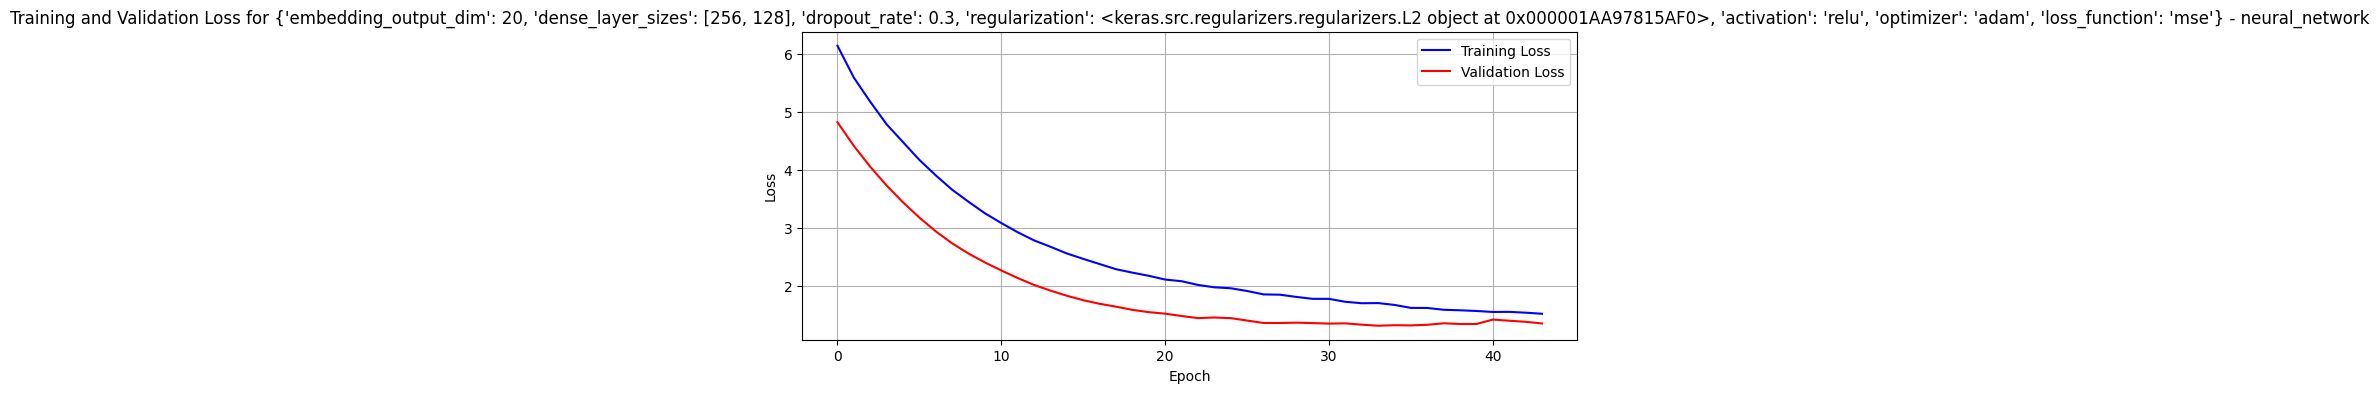


Training Neural Networks for BasinTC: Midland, FORMATION_CONDENSED: WCA: 100%|██████████| 1/1 [00:06<00:00,  6.25s/it]


Training completed for neural_network - {'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.3, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x000001AA97815AF0>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'} in 6.24 seconds
Training completed for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with config: {'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.3, 'regularization': <keras.src.regularizers.regularizers.L2 object at 0x000001AA97815AF0>, 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'}



Training ML models for BasinTC: Midland, FORMATION_CONDENSED: WCA:   0%|          | 0/3 [00:00<?, ?it/s]

Starting training for combination: BasinTC: Midland, FORMATION_CONDENSED: WCA with ML config: {'model_type': 'xgboost'}
Starting xgboost training with config: {}
Fitting 2 folds for each of 256 candidates, totalling 512 fits


Training ML models for BasinTC: Midland, FORMATION_CONDENSED: WCA:   0%|          | 0/3 [02:55<?, ?it/s]
  0%|          | 0/1 [03:02<?, ?it/s]


KeyboardInterrupt: 

In [47]:
# Assuming df, train_df, val_df, test_df are defined and contain the necessary columns
# unique_combinations = df[['BasinTC', 'FORMATION_CONDENSED']].drop_duplicates()
configurations = [
    {'embedding_output_dim': 20, 'dense_layer_sizes': [256, 128], 'dropout_rate': 0.3, 'regularization': l2(0.01), 'activation': 'relu', 'optimizer': 'adam', 'loss_function': 'mse'},
 #   {'embedding_output_dim': 15, 'dense_layer_sizes': [64, 32], 'dropout_rate': 0.2, 'regularization': l1(0.01), 'activation': 'relu', 'optimizer': 'rmsprop', 'loss_function': 'mse'}
]

ml_configurations = [
    {'model_type': 'xgboost'},
    {'model_type': 'random_forest'},
    {'model_type': 'decision_tree'}
]
# Assuming df, train_df, val_df, test_df are defined and contain the necessary columns
specific_combinations = df[
    (df['BasinTC'] == 'Midland') & 
    #(df['FORMATION_CONDENSED'].isin(['LSS', 'WCA', 'WCB', 'WCD']))
    (df['FORMATION_CONDENSED'].isin(['WCA']))
].drop_duplicates(subset=['BasinTC', 'FORMATION_CONDENSED'])
output_size = len(train_df[y_headers].columns)  # Ensure output_size is defined

# Dictionary to store task times
task_times = {}

# Execution
models = execute_training(
    specific_combinations, train_df, val_df, test_df, numerical_columns, categorical_columns, y_headers, output_size, df, task_times, mode='serial'  # Change mode to 'serial' for serial execution
)

# Print out the task times to identify slow tasks
print("Task times (in seconds):")
for task, duration in task_times.items():
    print(f"{task}: {duration:.2f} seconds")

In [ ]:
# Function to denormalize numerical data
def denormalize_data_input(data, scaler):
    return scaler.inverse_transform(data)
# Function to denormalize data and revert log transformation
def denormalize_data_output(data, scaler, log_transform_columns):
    denormalized_data = scaler.inverse_transform(data)
    denormalized_df = pd.DataFrame(denormalized_data, columns=scaler.get_feature_names_out())
    denormalized_df[log_transform_columns] = np.expm1(denormalized_df[log_transform_columns])
    if any('BuildupRate' in col for col in log_transform_columns):
        denormalized_df[log_transform_columns] = denormalized_df[log_transform_columns].replace(1, 0)
    return denormalized_df
# Function to decode categorical data
def decode_categorical(data, encoders, column_names):
    decoded_data = {}
    for i, col in enumerate(column_names):
        le = encoders[col]
        decoded_data[col] = le.inverse_transform(data[:, i].astype(int))
    return decoded_data
# Denormalize and decode the training DataFrame
def denormalize_and_decode(train_df, numerical_columns, categorical_columns, y_headers, input_scaler, output_scaler, encoders):
    # Denormalize numerical features
    train_df[numerical_columns] = denormalize_data_input(train_df[numerical_columns], input_scaler)
    #log_transform_columns = [col for col in y_headers if 'BuildupRate' in col or 'InitialProd' in col]
    log_transform_columns = [col for col in y_headers if 'InitialProd' in col]
    # Denormalize target features
    train_df[y_headers] = denormalize_data_output(train_df[y_headers], output_scaler, log_transform_columns)
    # Decode categorical features
    decoded_categorical = decode_categorical(train_df, encoders, categorical_columns)
    for col in categorical_columns:
        train_df[col] = decoded_categorical[col]
    return train_df

In [ ]:
# Function to generate hyperbolic decline curve
def hyperbolic_decline(t, qi, di, b):
    return qi / ((1 + b * di * t) ** (1/b))

def modified_hyperbolic(t, qi, Di, b, Dlim, IBU, MBU, buildup_method='Linear'):
    """
    Calculates the production rate using a modified hyperbolic decline model with an exponential buildup phase.
    
    Parameters:
    t (array-like): Time array (months).
    qi (float): Initial production rate after the build-up period (bbl/day).
    Di (float): Initial decline rate.
    b (float): Hyperbolic exponent.
    Dlim (float): Limiting decline rate for exponential decline.
    IBU (float): Initial build-up rate.
    MBU (int): Months for the build-up period.
    buildup_method (str): Method for buildup calculation ('Flat', 'Linear', 'Exp').

    Returns:
    array-like: Production rate at each time point.
    """
    # Ensure MBU is treated as an integer
    MBU = int(MBU)
    
    # Initialize the q_model array
    q_model = np.zeros_like(t)
    
    # Calculate build-up phase
    if MBU > 0:
        # Extract the buildup data
        buildup_time = t[t < MBU]
        
        if buildup_method == 'Flat':
            Rate_0 = qi
            slope = 0
            buildup_rate = Rate_0 + slope * buildup_time
        elif buildup_method == 'Linear':
            Res_fun = lambda params, x, y: np.array(params[0] + params[1] * x - y)
            result = optimize.least_squares(Res_fun, x0=[IBU,qi ], args=[buildup_time, qi * np.ones_like(buildup_time)])
            Rate_0 = result.x[0]
            slope = result.x[1]
            buildup_rate = Rate_0 + slope * buildup_time
        elif buildup_method == 'Exp':
            Res_fun = lambda params, x, y: np.array(params[0] * np.exp(params[1] * x) - y)
            result = optimize.least_squares(Res_fun, x0=[IBU,qi], args=[buildup_time, qi * np.ones_like(buildup_time)])
            Rate_0 = result.x[0]
            slope = result.x[1]
            buildup_rate = Rate_0 * np.exp(slope * buildup_time)
        else:
            raise ValueError("Unknown buildup method. Use 'Flat', 'Linear', or 'Exp'.")
        
        q_model[t < MBU] = buildup_rate

    # Convert decline rates
    Di = ((1 - 0.01 * Di) ** (-b) - 1) / (12 * b)
    Dlim = ((1 - 0.01 * Dlim) ** (-b) - 1) / (12 * b)
    
    # Calculate switch point
    qlim = qi * (Dlim / Di) ** (1.0 / b)
    tlim = ((qi / qlim) ** (b) - 1.0) / (b * Di)
    
    # Separate hyperbolic and exponential segments
    t_hyp = t[(t >= MBU) & (t < tlim)]
    t_exp = t[t >= tlim]
    
    # Calculate model response
    q_model_hyp = qi * (1.0 + b * Di * (t_hyp - MBU)) ** (-1.0 / b)
    q_model_exp = qlim * np.exp(-Dlim * (t_exp - tlim))
    
    # Combine all segments
    q_model[(t >= MBU) & (t < tlim)] = q_model_hyp
    q_model[t >= tlim] = q_model_exp

    # Handle potential infinities or large values
    q_model = np.nan_to_num(q_model, nan=0.0, posinf=np.finfo(float).max, neginf=0.0)
    
    return q_model
# Function to plot decline curves in semi-logarithmic scale
def plot_decline_curves(time, actual, predicted, title):
    plt.figure(figsize=(10, 6))
    plt.plot(time, actual, 'b-o', label='Actual')
    plt.plot(time, predicted, 'r--x', label='Predicted')
    plt.yscale('log')
    plt.ylim(1, 100000)
    plt.title(title)
    plt.xlabel('Time (Months)')
    plt.ylabel('Production Rate (bbl/day)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--')
    plt.show()

# Function to generate production rates
def generate_production_rates(y_pred_denormalized, y_true_denormalized, headers, time):
    predicted_productions = []
    actual_productions = []

    for idx in range(len(y_pred_denormalized)):
        qi_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_InitialProd')]
        di_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_DiCoefficient')]
        b_pred  = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_BCoefficient')]
        IBU_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_BuildupRate')]
        MBU_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_MonthsInProd')]
        Dlim_pred = y_pred_denormalized.iloc[idx, headers.index('Oil_Params_P50_LimDeclineRate')]
        
        qi_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_InitialProd')]
        di_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_DiCoefficient')]
        b_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_BCoefficient')]
        IBU_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_BuildupRate')]
        MBU_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_MonthsInProd')]
        Dlim_true = y_true_denormalized.iloc[idx, headers.index('Oil_Params_P50_LimDeclineRate')]
        
        predicted_production = modified_hyperbolic(time, qi_pred, di_pred, b_pred, Dlim_pred, IBU_pred, MBU_pred)
        actual_production = modified_hyperbolic(time, qi_true, di_true, b_true, Dlim_true, IBU_true, MBU_true)
        # predicted_production = hyperbolic_decline(time, qi_pred, di_pred, b_pred)
        # actual_production = hyperbolic_decline(time, qi_true, di_true, b_true)
        
        predicted_productions.append(predicted_production)
        actual_productions.append(actual_production)

    return predicted_productions, actual_productions


# Function to calculate errors
def calculate_errors(predicted_productions, actual_productions):
    errors = []

    for pred, actual in zip(predicted_productions, actual_productions):
        mse = mean_squared_error(actual, pred)
        errors.append(mse)

    return errors

# Function to identify best and worst matches
def identify_best_worst_matches(errors, y_true_denormalized, y_pred_denormalized):
    best_match_idx = np.argmin(errors)
    worst_match_idx = np.argmax(errors)

    best_match_true = y_true_denormalized.iloc[best_match_idx]
    best_match_pred = y_pred_denormalized.iloc[best_match_idx]

    worst_match_true = y_true_denormalized.iloc[worst_match_idx]
    worst_match_pred = y_pred_denormalized.iloc[worst_match_idx]

    return best_match_true, best_match_pred, worst_match_true, worst_match_pred, best_match_idx, worst_match_idx

# Function to plot decline curves in semi-logarithmic scale
def plot_decline_curves(time, actual, predicted, title):
    plt.figure(figsize=(10, 6))
    plt.plot(time, actual, 'b-o', label='Actual')
    plt.plot(time, predicted, 'r--x', label='Predicted')
    plt.yscale('log')
    plt.ylim(1, 100000)
    plt.title(title)
    plt.xlabel('Time (Months)')
    plt.ylabel('Production Rate (bbl/day)')
    plt.legend()
    plt.grid(True, which='both', linestyle='--')
    plt.show()
    


In [ ]:
# Define the prediction function
#@tf.function(reduce_retracing=True)
def predict_with_model(model, numerical_data, categorical_data):
    if isinstance(model, Model):  # Keras model
        return model.predict([numerical_data] + categorical_data)
    else:  # Sklearn model
        import pandas as pd
        data_combined = np.hstack([numerical_data] + categorical_data)
        combined_df = pd.DataFrame(data_combined, columns=numerical_columns + categorical_columns)
        return model.predict(combined_df)

In [ ]:
years = 5
time = np.linspace(1, 12*years, 12*years)  # 5 Years

# Evaluate the models
# Evaluate the models
evaluation_results = {}
best_performing_models = {}
for (basin, formation, config_str), model in models.items():
    # Filter the test data for the specific basin and formation
    combo_test = filter_by_basin_and_formation(test_df, basin, formation)
    
    # Extract numerical and categorical data from the filtered test set
    numerical_data = combo_test[numerical_columns].values
    categorical_data = [combo_test[col].astype(int).values.reshape(-1, 1) for col in categorical_columns]
    
    # Prepare the target values (y_true)
    y_true = combo_test[y_headers].values  # Use entire y_headers as output

    # Predict outputs using the model
    y_pred = predict_with_model(model, numerical_data, categorical_data)

    # Denormalize predictions and actual values
    y_pred_denormalized = denormalize_data_output(y_pred, output_scaler, log_transform_columns)
    y_true_denormalized = denormalize_data_output(y_true, output_scaler, log_transform_columns)
    
    # Generate production rates
    predicted_productions, actual_productions = generate_production_rates(y_pred_denormalized, y_true_denormalized, y_headers, time)

    # Calculate errors
    errors = calculate_errors(predicted_productions, actual_productions)

    # Identify best and worst matches
    best_match_true, best_match_pred, worst_match_true, worst_match_pred, best_match_idx, worst_match_idx = identify_best_worst_matches(errors, y_true_denormalized, y_pred_denormalized)

    # Plot the best match
    best_actual_production = actual_productions[best_match_idx]
    best_predicted_production = predicted_productions[best_match_idx]
    plot_decline_curves(time, best_actual_production, best_predicted_production, f'Best Match Hyperbolic Decline Curve for {basin} - {formation}')

    # Plot the worst match
    worst_actual_production = actual_productions[worst_match_idx]
    worst_predicted_production = predicted_productions[worst_match_idx]
    plot_decline_curves(time, worst_actual_production, worst_predicted_production, f'Worst Match Hyperbolic Decline Curve for {basin} - {formation}')

    # Calculating evaluation metrics
    if y_true_denormalized.shape == y_pred_denormalized.shape:
        mse = mean_squared_error(y_true_denormalized, y_pred_denormalized)
        mae = mean_absolute_error(y_true_denormalized, y_pred_denormalized)
        evaluation_results[(basin, formation, config_str)] = {'MSE': mse, 'MAE': mae}
        print(f"Performance for Basin: {basin}, Formation: {formation}, Config: {config_str} - MSE: {mse:.4f}, MAE: {mae:.4f}")
        
        # Update best performing model
        if (basin, formation) not in best_performing_models or mse < best_performing_models[(basin, formation)]['MSE']:
            best_performing_models[(basin, formation)] = {'MSE': mse, 'MAE': mae, 'config_str': config_str, 'model': model}
    else:
        print(f"Shape mismatch between y_true {y_true_denormalized.shape} and y_pred {y_pred_denormalized.shape}, check data preparation steps.")
# Print the best performing model for each basin and formation
for (basin, formation), best_model_info in best_performing_models.items():
    print(f"Best Performing Model for Basin: {basin}, Formation: {formation} - Config: {best_model_info['config_str']} - MSE: {best_model_info['MSE']:.4f}, MAE: {best_model_info['MAE']:.4f}")